# $(SASA) Regular$

$loss = \alpha \times mse(\hat{\theta_i^a}, \hat{\theta_j^a}) + \beta \times (1-mse(\hat{\theta_i^a}, \hat{\theta_k^b})) + \gamma \times mse(\hat{s_{i+2}^a}, y) + \lambda(\hat{\theta_i^a}^2 + \hat{\theta_k^b}^2 + \hat{\theta_j^a}^2)$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [2]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [3]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
930,15,38,"(0.4545373771214862, 0.5810082803318615)","(-0.014, 0.555, 0.059, -0.75)",1,1.0,"(-0.003, 0.751, 0.044, -1.067)",0.0,1.0,"(0.012, 0.553, 0.023, -0.712)"
1903,7,76,"(0.0250474928798763, 0.8242933987226606)","(0.064, 0.237, -0.001, -0.131)",0,1.0,"(0.069, 0.048, -0.004, 0.037)",0.0,1.0,"(0.07, -0.142, -0.003, 0.204)"
1553,7,64,"(0.3183694304142259, 0.9452629977131142)","(0.087, 0.196, -0.091, -0.285)",0,1.0,"(0.091, 0.007, -0.096, -0.12)",0.0,1.0,"(0.091, -0.182, -0.099, 0.044)"
1568,22,64,"(0.3183694304142259, 0.9452629977131142)","(0.037, 0.019, -0.11, -0.39)",1,1.0,"(0.037, 0.21, -0.118, -0.594)",0.0,1.0,"(0.042, 0.021, -0.13, -0.435)"
672,60,23,"(0.2125978932043111, 0.6111562190979459)","(-0.568, -1.841, -0.073, 0.768)",1,1.0,"(-0.605, -1.646, -0.058, 0.487)",0.0,1.0,"(-0.638, -1.839, -0.048, 0.731)"
...,...,...,...,...,...,...,...,...,...,...
95,7,5,"(0.3551867425587211, 0.959194989729514)","(0.046, 0.222, -0.013, -0.22)",0,1.0,"(0.051, 0.031, -0.017, -0.035)",0.0,1.0,"(0.051, -0.159, -0.018, 0.149)"
903,8,37,"(0.4975531073717145, 0.2612437398996861)","(-0.011, -0.409, 0.065, 1.382)",1,1.0,"(-0.019, -0.194, 0.092, 0.65)",1.0,1.0,"(-0.023, 0.02, 0.105, -0.056)"
2396,19,94,"(0.4377652476268179, 0.9729568415243506)","(-0.112, -0.171, 0.129, 0.355)",1,1.0,"(-0.115, 0.018, 0.136, 0.186)",1.0,1.0,"(-0.115, 0.208, 0.14, 0.019)"
2027,21,80,"(0.077800491974935, 0.5006250071926374)","(-0.019, -0.236, -0.038, 0.149)",1,1.0,"(-0.023, -0.041, -0.035, -0.15)",0.0,1.0,"(-0.024, -0.235, -0.038, 0.126)"


In [4]:
model = Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000, alpha=loss_param, beta=loss_param, lambda_=loss_param)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_positive,mse_negative,mse_s,regularize,transition,reward
0,0,"[0.03226214274764061, 0.6547549366950989]","[0.03434141352772713, 0.6506217122077942]","[0.12329919636249542, 0.39550545811653137, 0.0...",0.795629,1.380301,1.432435
1,1,"[0.03229954093694687, 0.6522817611694336]","[0.03436524420976639, 0.6483425498008728]","[0.12020692229270935, 0.3907439410686493, 0.01...",0.796310,1.366198,1.430477
2,2,"[0.03235764056444168, 0.649836003780365]","[0.034409523010253906, 0.6460917592048645]","[0.11716599762439728, 0.3860098421573639, 0.01...",0.797012,1.352205,1.428467
3,3,"[0.032435666769742966, 0.6474220156669617]","[0.03447379916906357, 0.6438767313957214]","[0.11417343467473984, 0.381301611661911, 0.016...",0.797735,1.338314,1.426467
4,4,"[0.03253418207168579, 0.6450368762016296]","[0.034559089690446854, 0.6416940689086914]","[0.11122961342334747, 0.3766171634197235, 0.01...",0.798479,1.324527,1.424492


In [5]:
data.training_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__
930,15,38,"(0.4545373771214862, 0.5810082803318615)","(-0.014, 0.555, 0.059, -0.75)",1,1.0,"(-0.003, 0.751, 0.044, -1.067)",0.0,1.0,"(0.012, 0.553, 0.023, -0.712)"
1903,7,76,"(0.0250474928798763, 0.8242933987226606)","(0.064, 0.237, -0.001, -0.131)",0,1.0,"(0.069, 0.048, -0.004, 0.037)",0.0,1.0,"(0.07, -0.142, -0.003, 0.204)"
1553,7,64,"(0.3183694304142259, 0.9452629977131142)","(0.087, 0.196, -0.091, -0.285)",0,1.0,"(0.091, 0.007, -0.096, -0.12)",0.0,1.0,"(0.091, -0.182, -0.099, 0.044)"
1568,22,64,"(0.3183694304142259, 0.9452629977131142)","(0.037, 0.019, -0.11, -0.39)",1,1.0,"(0.037, 0.21, -0.118, -0.594)",0.0,1.0,"(0.042, 0.021, -0.13, -0.435)"
672,60,23,"(0.2125978932043111, 0.6111562190979459)","(-0.568, -1.841, -0.073, 0.768)",1,1.0,"(-0.605, -1.646, -0.058, 0.487)",0.0,1.0,"(-0.638, -1.839, -0.048, 0.731)"


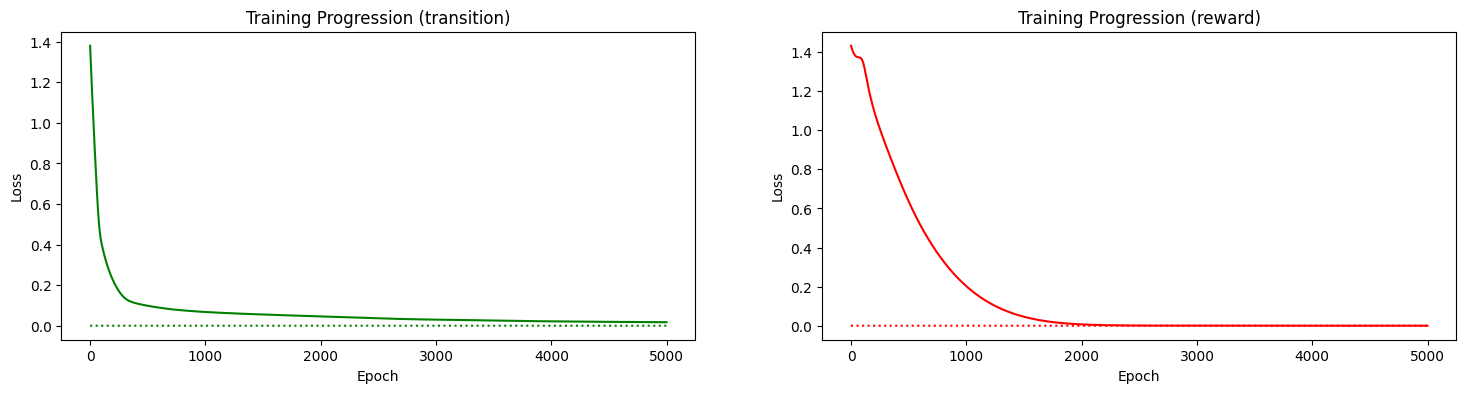

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

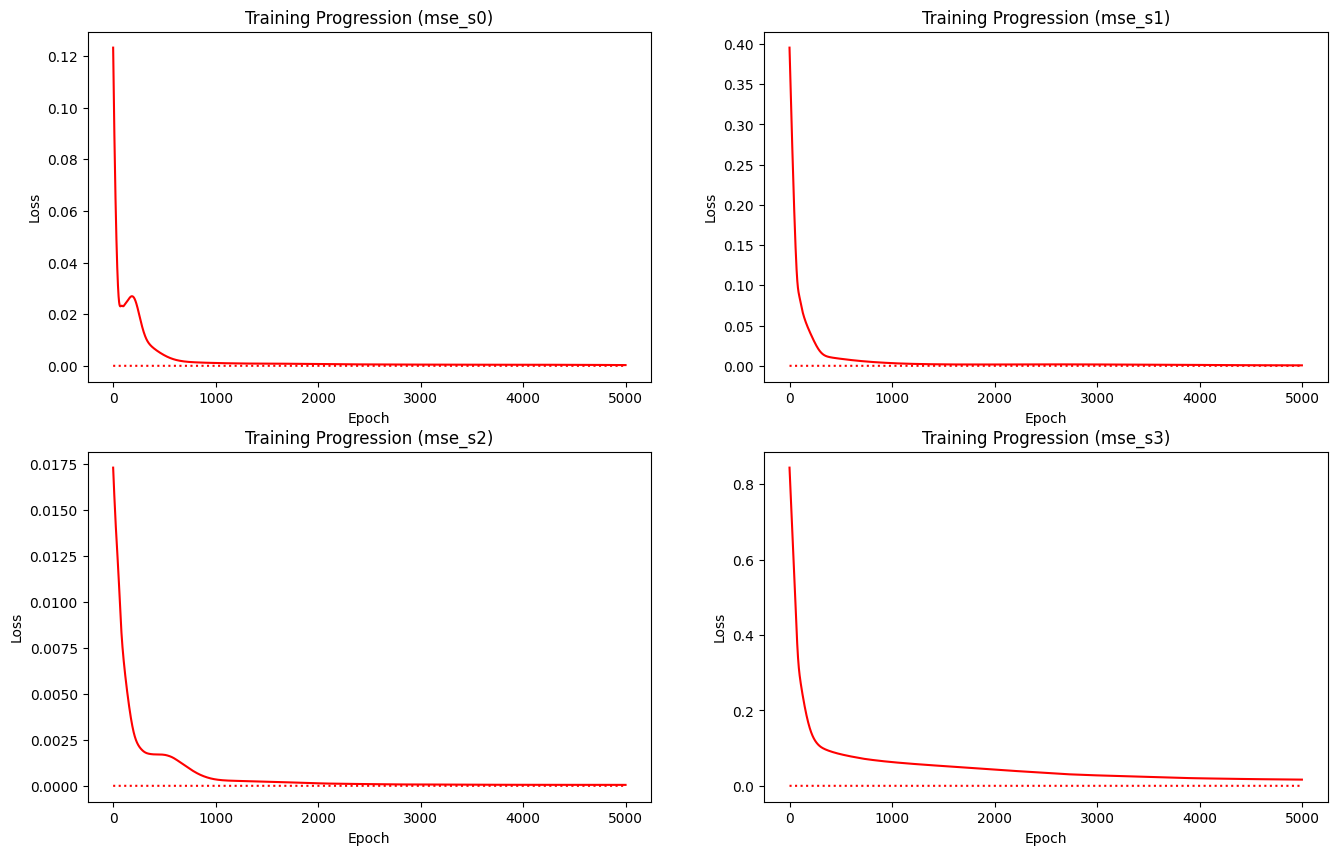

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

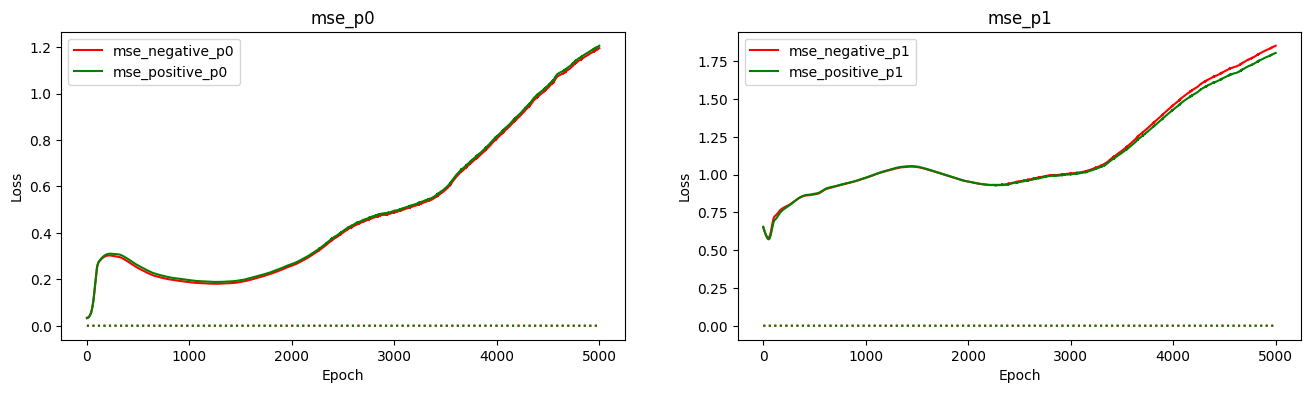

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,(neg, pos) in enumerate(zip(expansions['mse_negative'], expansions['mse_positive'])):
    data.plot_training_loss(axs[i], df[neg], 'r')
    data.plot_training_loss(axs[i], df[pos], 'g')
    axs[i].set_title(f'mse_p{i}')
    axs[i].legend()

plt.show()

## Params

In [9]:
import pandas as pd

training_params = pd.DataFrame(y.numpy(), columns=model.targets_lables)

expansions = {
    'p': ['p0', 'p1']
}
df_trainning = get_data_expanded(data.training_data.loc[(data.training_data.epoch==499)], expansions)

df_trainning_p = pd.DataFrame([], columns=['epoch', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1', 'p0', 'p1'])
for epoch in df_trainning.epoch.unique():
    copy = df_trainning[df_trainning.epoch == epoch].copy()[['epoch', 'p0', 'p1']].reset_index(drop=True)
    copy[['sample', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']] = training_params.copy()[['positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']].reset_index()
    df_trainning_p = pd.concat([df_trainning_p, copy])

df_trainning_p.head()

/tmp/ipykernel_2393/580248604.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_trainning_p = pd.concat([df_trainning_p, copy])


,epoch,positive_p0,positive_p1,negative_p0,negative_p1,p0,p1,sample
0,499,0.454537,0.581008,0.093786,0.329204,0.624056,0.240402,0.0
1,499,0.025047,0.824293,0.029917,0.523248,0.598381,-0.096409,1.0
2,499,0.318369,0.945263,0.240325,0.729884,0.494064,-0.071356,2.0
3,499,0.318369,0.945263,0.162168,0.484361,0.454634,-0.013421,3.0
4,499,0.212598,0.611156,0.152397,0.519114,-0.193068,-0.279653,4.0


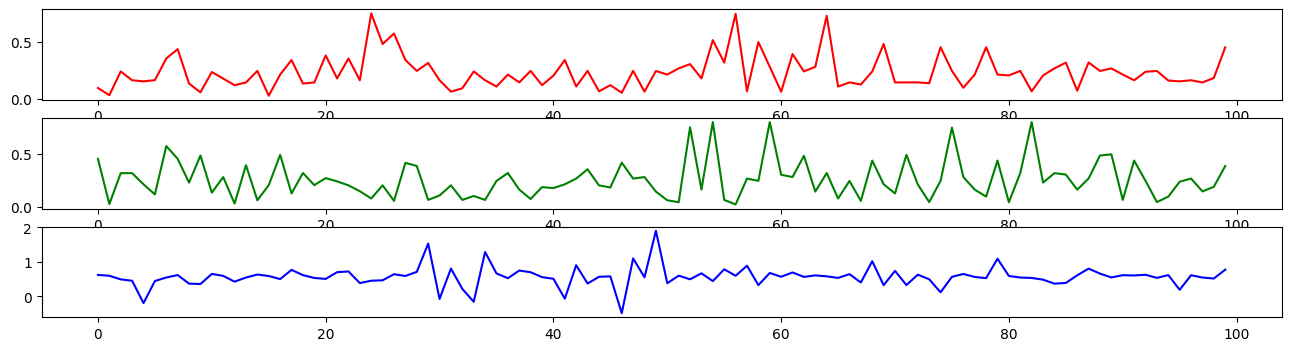

In [10]:
fig, axs = plt.subplots(3, 1, figsize=(16, 4))

axs[0].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['negative_p0'], color='r', label='negative')
axs[1].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['positive_p0'], color='g', label='positve')
axs[2].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['p0'], color='b', label='estimative')

plt.show()

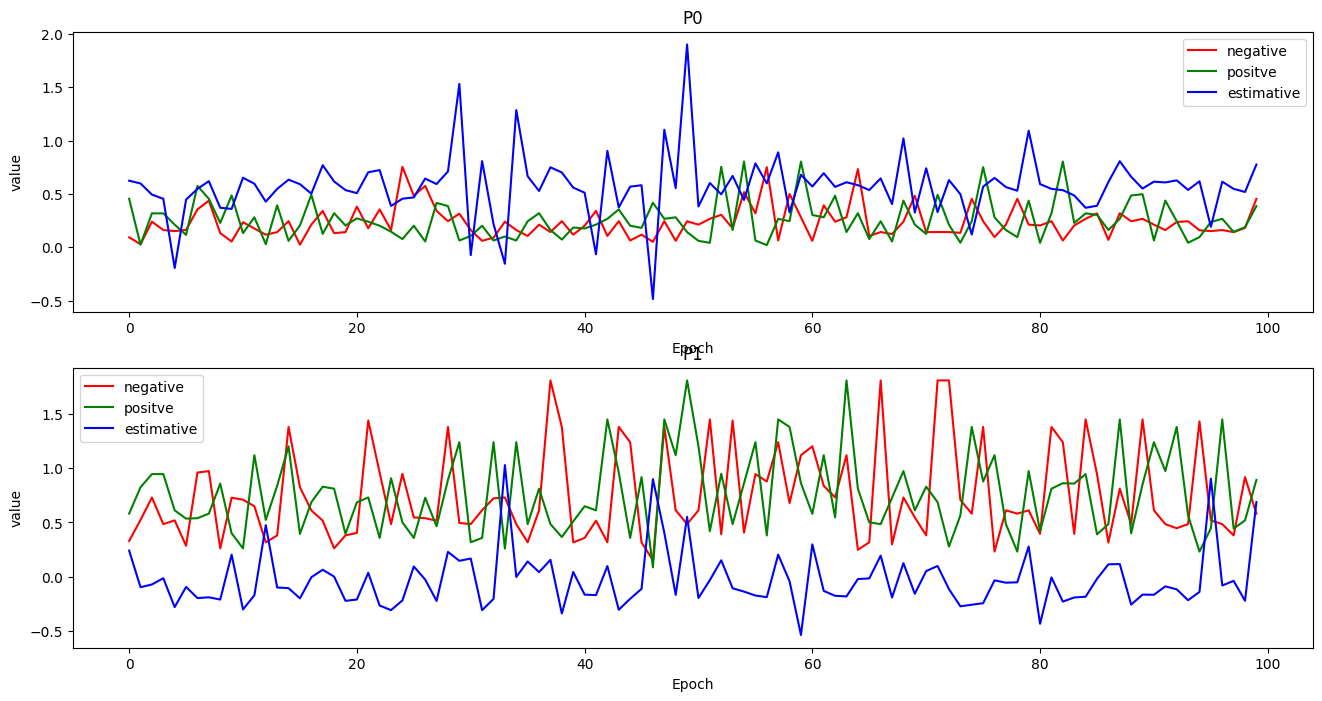

In [11]:
fig, axs = plt.subplots(2,1, figsize=(16, 8))

# df = df_trainning_p.groupby('epoch').mean()
# df = df_trainning_p.groupby('sample').mean()
df = df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]

axs[0].plot(df['negative_p0'], color='r', label='negative')
axs[0].plot(df['positive_p0'], color='g', label='positve')
axs[0].plot(df['p0'], color='b', label='estimative')

axs[0].set_ylabel('value')
axs[0].set_xlabel('Epoch')
axs[0].set_title(f'P0')
axs[0].legend()

axs[1].plot(df['negative_p1'], color='r', label='negative')
axs[1].plot(df['positive_p1'], color='g', label='positve')
axs[1].plot(df['p1'], color='b', label='estimative')

axs[1].set_ylabel('value')
axs[1].set_xlabel('Epoch')
axs[1].set_title(f'P1')
axs[1].legend()

plt.show()

## Best and worst episodes

In [12]:
data.evaluate_model(model, path='training_data.csv')
results = data.get_evaluation_metrics()
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse,rse_normalized
0,0,0,"(0.0730412080386606, 0.3656961190344961)","(0.011, 0.034, 0.014, 0.009)",0,1.0,"(0.012, -0.165, 0.014, 0.407)",0.0,1.0,"(0.009, -0.365, 0.023, 0.806)",...,0.002,0.000,0.060,0.0,0.006452,0.007752,0.000000,0.026247,0.063,0.024938
1,1,0,"(0.0730412080386606, 0.3656961190344961)","(0.012, -0.165, 0.014, 0.407)",0,1.0,"(0.009, -0.365, 0.023, 0.806)",0.0,1.0,"(0.001, -0.565, 0.039, 1.207)",...,0.024,0.002,0.044,0.0,0.051613,0.093023,0.036364,0.019248,0.078,0.031172
2,2,0,"(0.0730412080386606, 0.3656961190344961)","(0.009, -0.365, 0.023, 0.806)",0,1.0,"(0.001, -0.565, 0.039, 1.207)",0.0,1.0,"(-0.01, -0.766, 0.063, 1.616)",...,0.025,0.004,0.009,0.0,0.122581,0.096899,0.072727,0.003937,0.057,0.022444
3,3,0,"(0.0730412080386606, 0.3656961190344961)","(0.001, -0.565, 0.039, 1.207)",0,1.0,"(-0.01, -0.766, 0.063, 1.616)",1.0,1.0,"(-0.025, -0.567, 0.095, 1.25)",...,0.012,0.004,0.039,0.0,0.051613,0.046512,0.072727,0.017060,0.063,0.024938
4,4,0,"(0.0730412080386606, 0.3656961190344961)","(-0.01, -0.766, 0.063, 1.616)",1,1.0,"(-0.025, -0.567, 0.095, 1.25)",1.0,1.0,"(-0.036, -0.369, 0.12, 0.9)",...,0.014,0.003,0.117,0.0,0.096774,0.054264,0.054545,0.051181,0.149,0.060682


In [13]:
rmse = results[['episode', 'rse_s0', 'rse_s1', 'rse_s2', 'rse_s3']].groupby('episode').mean().reset_index()
rmse['rmse'] = rmse.rse_s0 + rmse.rse_s1 + rmse.rse_s2 + rmse.rse_s3
rmse_sorted = rmse.sort_values(by='rmse')
epis = rmse.shape[0]

best_episodes = rmse_sorted.head(3).episode.values
worst_episodes = rmse_sorted.tail(3).episode.values
print(f'{best_episodes=}', f'{worst_episodes=}')

best_episodes=array([11, 51, 49]) worst_episodes=array([47, 32, 20])


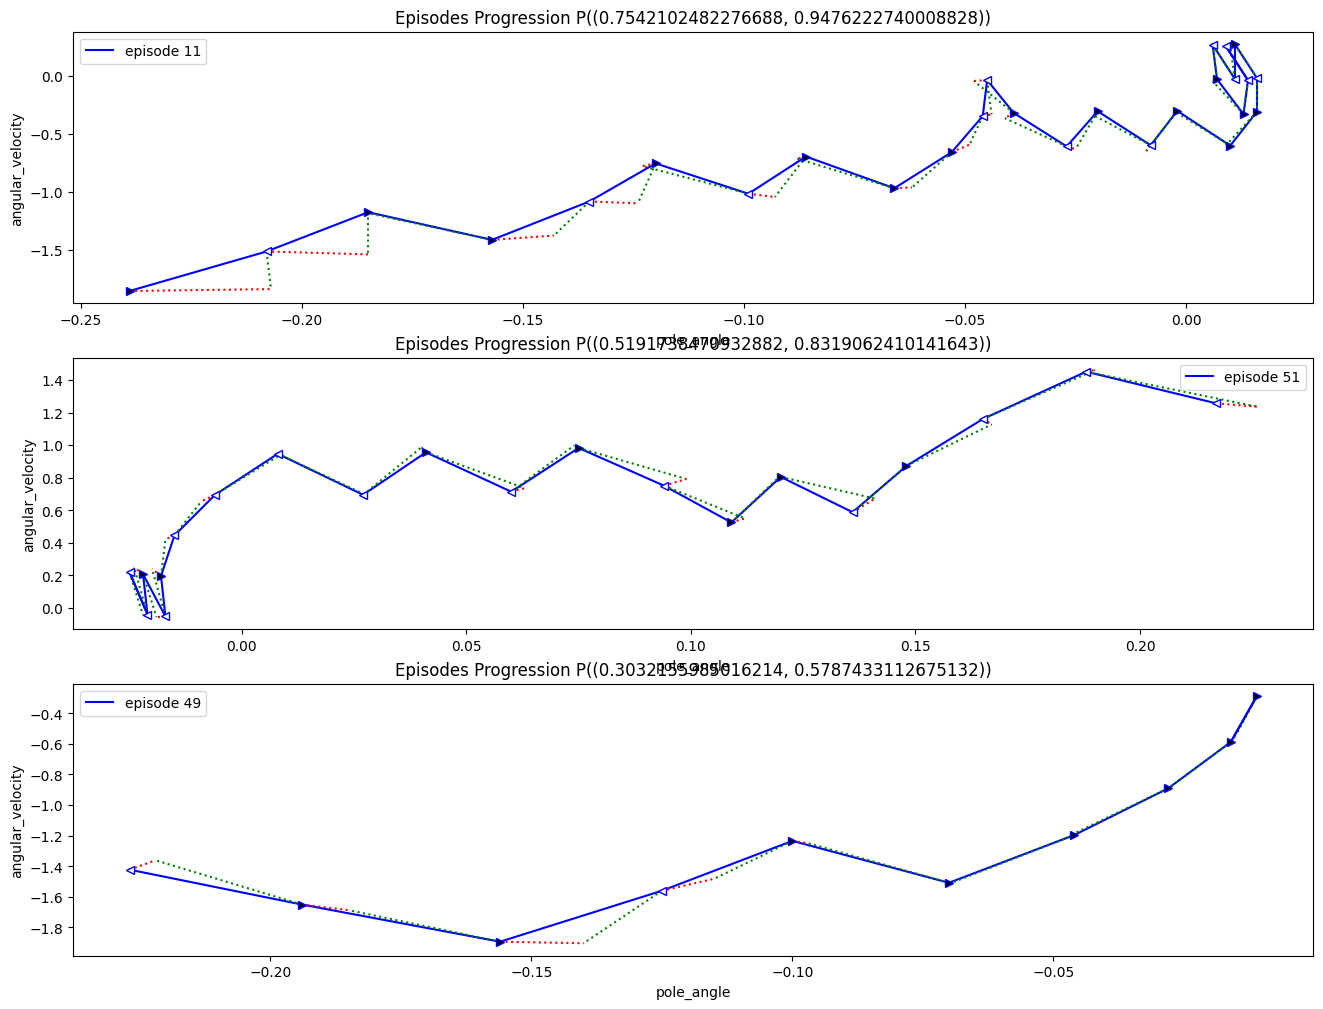

In [14]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(best_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

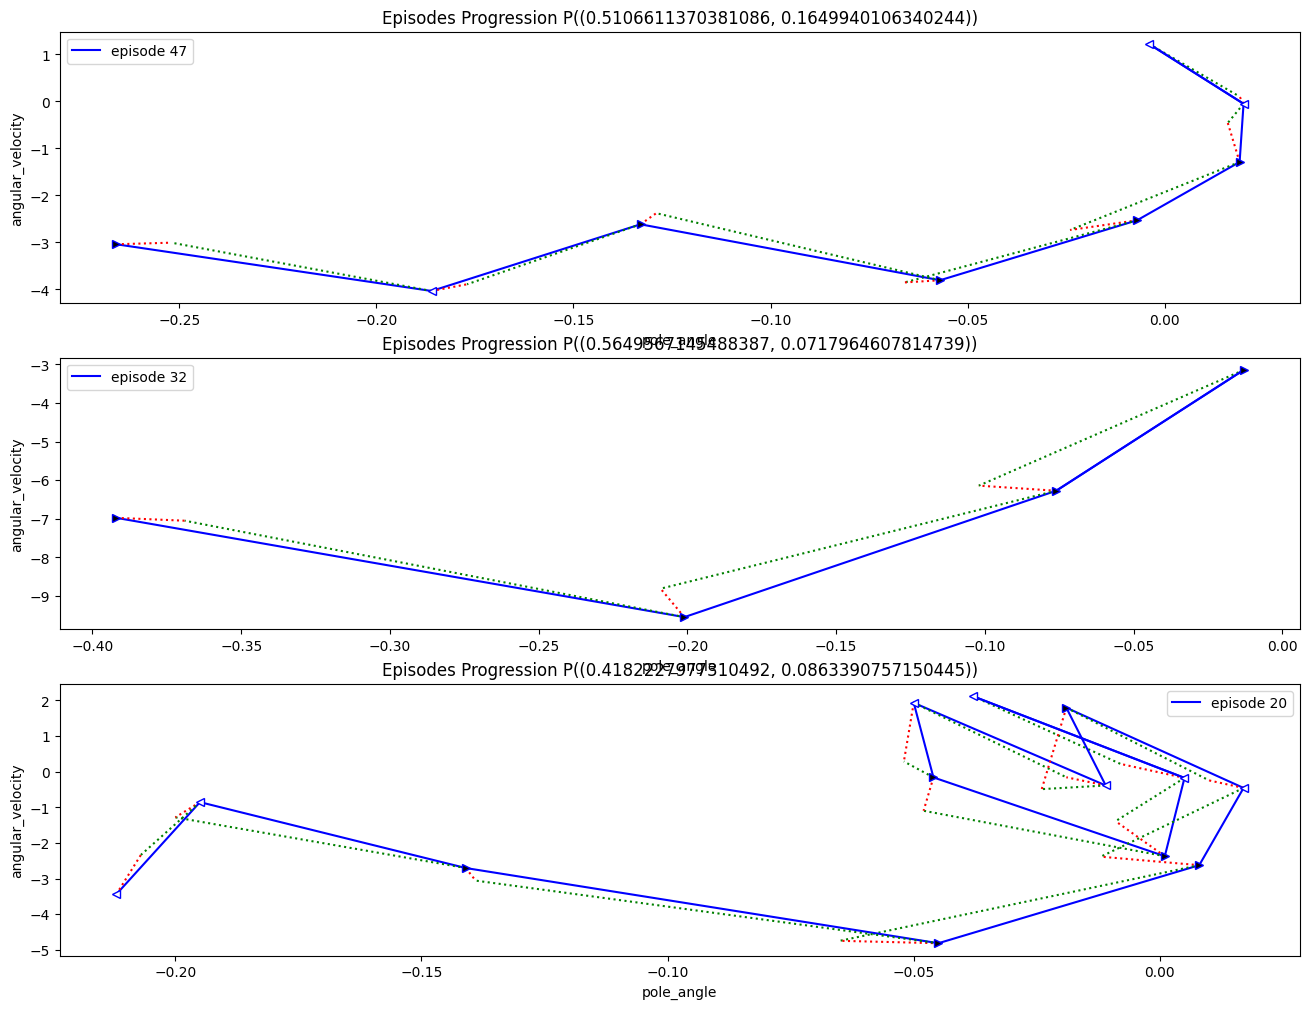

In [15]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(worst_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

## Kmeans

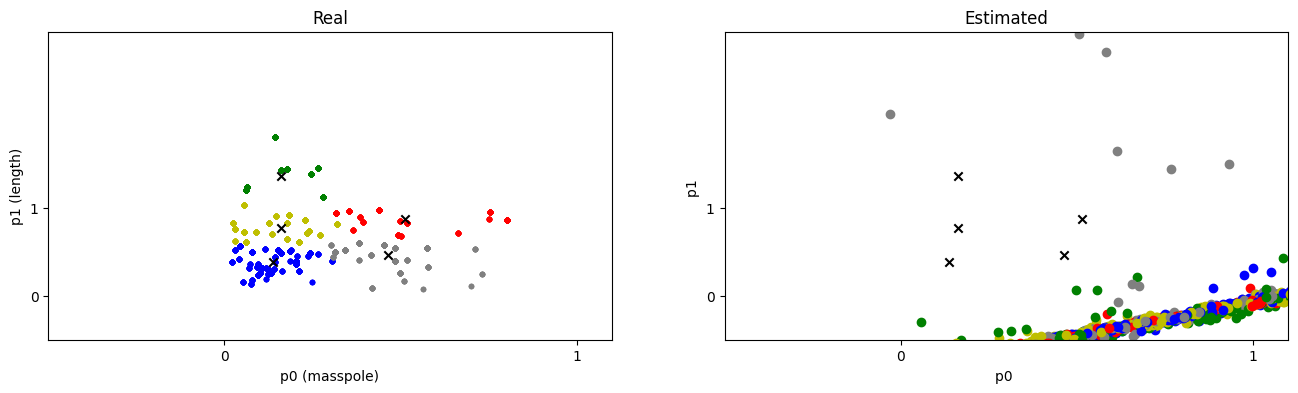

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
data.plot_clusters(axs, results)
plt.show()

# Evaluation

In [17]:
data.evaluate_model(model, path='testing_data.csv')
results = data.get_evaluation_metrics()
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse,rse_normalized
0,0,0,"(0.5280280669895349, 0.1691488904272192)","(-0.018, -0.046, 0.013, -0.019)",0,1.0,"(-0.019, -0.285, 0.013, 1.258)",0.0,1.0,"(-0.025, -0.525, 0.038, 2.534)",...,0.006,0.009,0.382,0.0,0.011173,0.025862,0.18,0.213527,0.399,0.210753
1,1,0,"(0.5280280669895349, 0.1691488904272192)","(-0.019, -0.285, 0.013, 1.258)",0,1.0,"(-0.025, -0.525, 0.038, 2.534)",1.0,1.0,"(-0.035, -0.288, 0.088, 1.326)",...,0.123,0.009,0.068,0.0,0.564246,0.530172,0.18,0.038010,0.301,0.158065
2,2,0,"(0.5280280669895349, 0.1691488904272192)","(-0.025, -0.525, 0.038, 2.534)",1,1.0,"(-0.035, -0.288, 0.088, 1.326)",0.0,1.0,"(-0.041, -0.532, 0.115, 2.694)",...,0.007,0.011,0.463,0.0,0.055866,0.030172,0.22,0.258804,0.491,0.260215
3,3,0,"(0.5280280669895349, 0.1691488904272192)","(-0.035, -0.288, 0.088, 1.326)",0,1.0,"(-0.041, -0.532, 0.115, 2.694)",1.0,1.0,"(-0.052, -0.3, 0.169, 1.601)",...,0.141,0.008,0.151,0.0,0.547486,0.607759,0.16,0.084405,0.398,0.210215
4,4,0,"(0.5280280669895349, 0.1691488904272192)","(-0.041, -0.532, 0.115, 2.694)",1,1.0,"(-0.052, -0.3, 0.169, 1.601)",0.0,1.0,"(-0.058, -0.546, 0.201, 3.045)",...,0.008,0.014,0.410,0.0,0.100559,0.034483,0.28,0.229178,0.450,0.238172


In [ ]:
results[['rse_s0','rse_s1','rse_s2','rse_s3','rse_r','rse_s0_normalized','rse_s1_normalized','rse_s2_normalized','rse_s3_normalized', 'rse']].describe()

,rse_s0,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse,rse_normalized
count,2127.000000,2127.000000,2127.000000,2127.000000,2127.0,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000
mean,0.011175,0.015361,0.004177,0.095962,0.0,0.062432,0.066209,0.083535,0.053640,0.126675,0.064341
std,0.014612,0.017710,0.005507,0.126551,0.0,0.081630,0.076335,0.110142,0.070738,0.134244,0.072174
min,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.007000,0.000000
25%,0.003000,0.005000,0.001000,0.028000,0.0,0.016760,0.021552,0.020000,0.015651,0.053000,0.024731
50%,0.007000,0.011000,0.003000,0.061000,0.0,0.039106,0.047414,0.060000,0.034097,0.090000,0.044624
75%,0.013000,0.020000,0.005000,0.118000,0.0,0.072626,0.086207,0.100000,0.065959,0.152000,0.077957
max,0.179000,0.232000,0.050000,1.789000,0.0,1.000000,1.000000,1.000000,1.000000,1.867000,1.000000


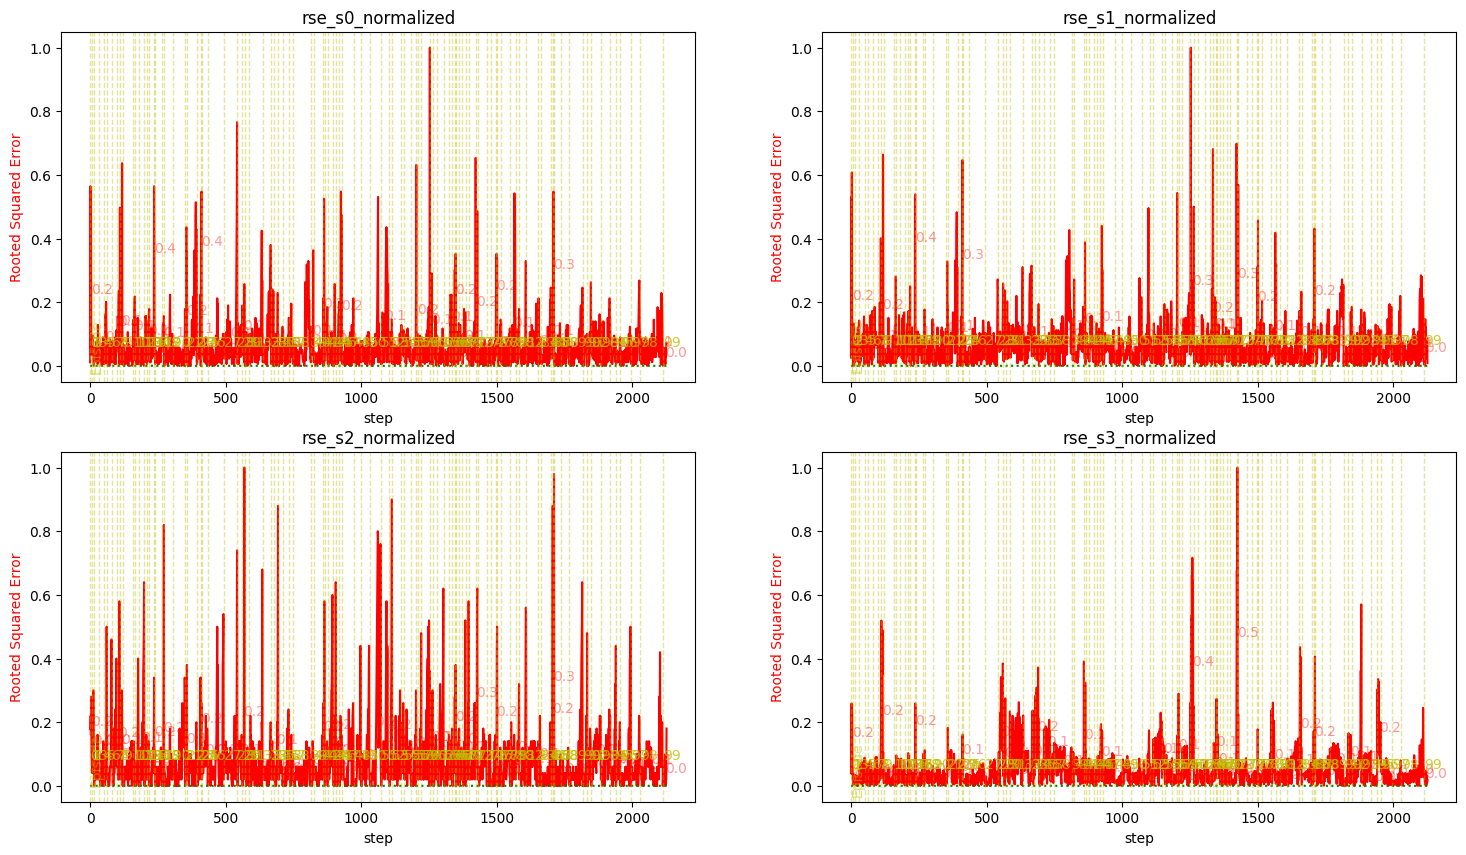

In [19]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0_normalized')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1_normalized')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2_normalized')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3_normalized')

plt.show()

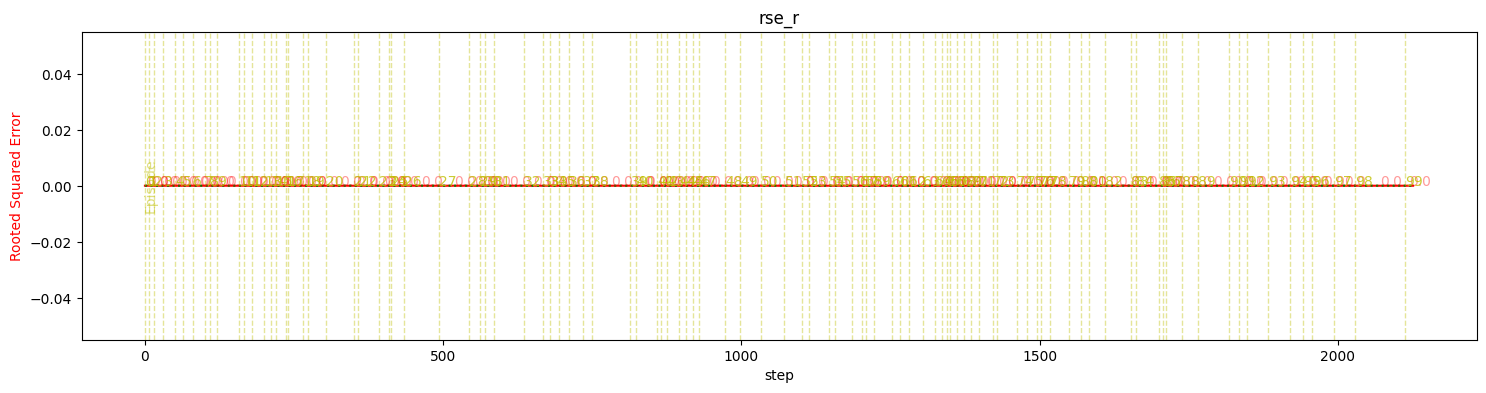

In [20]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

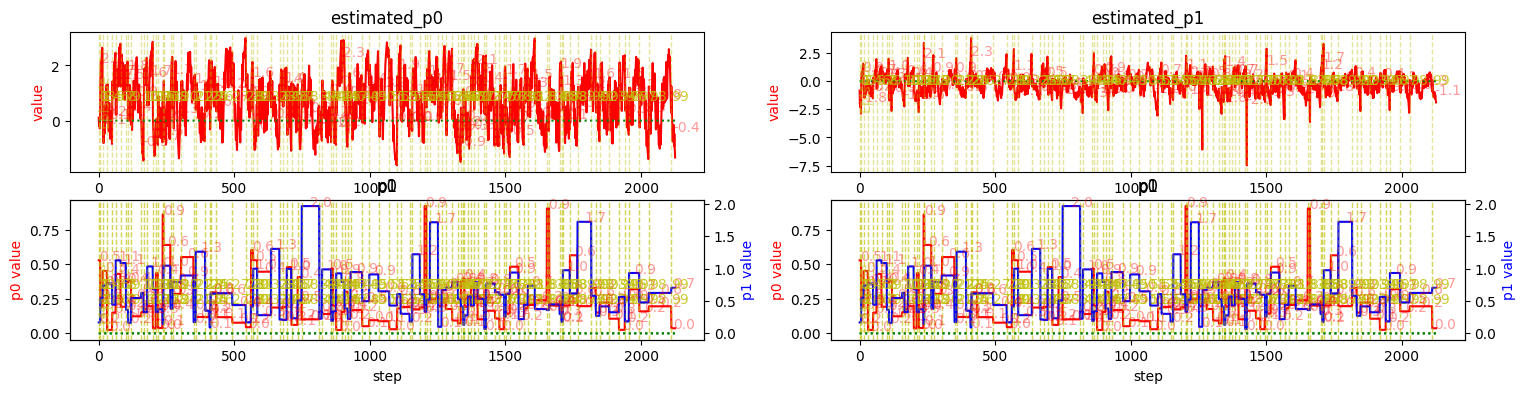

In [ ]:
import numpy as np

n = 10

df = results[['episode', 'estimated_p0', 'estimated_p1', 'p0', 'p1']].groupby("episode").mean().reset_index()
df['dist_p0'] = np.sqrt(np.pow(df['estimated_p0']-df['p0'], 2))
df['dist_p1'] = np.sqrt(np.pow(df['estimated_p1']-df['p1'], 2))
df['dist'] = df['dist_p0'] + df['dist_p1']
worst = df.loc[df.rank(ascending=False)['dist']<=n].episode
df = results[results['episode'].isin(worst)].reset_index(drop=True)

fig, axs = plt.subplots(2, 2, figsize=(18,4))
data.plot_value_through_episodes(axs[0][0], df, 'estimated_p0', y_label='value')
data.plot_value_through_episodes(axs[0][1], df, 'estimated_p1', y_label='value')

data.plot_value_through_episodes(axs[1][0], df, 'p0', y_label='p0 value')
data.plot_value_through_episodes(axs[1][0].twinx(), df, 'p1', y_label='p1 value', color='b')

data.plot_value_through_episodes(axs[1][1], df, 'p0', y_label='p0 value')
data.plot_value_through_episodes(axs[1][1].twinx(), df, 'p1', y_label='p1 value', color='b')

plt.show()

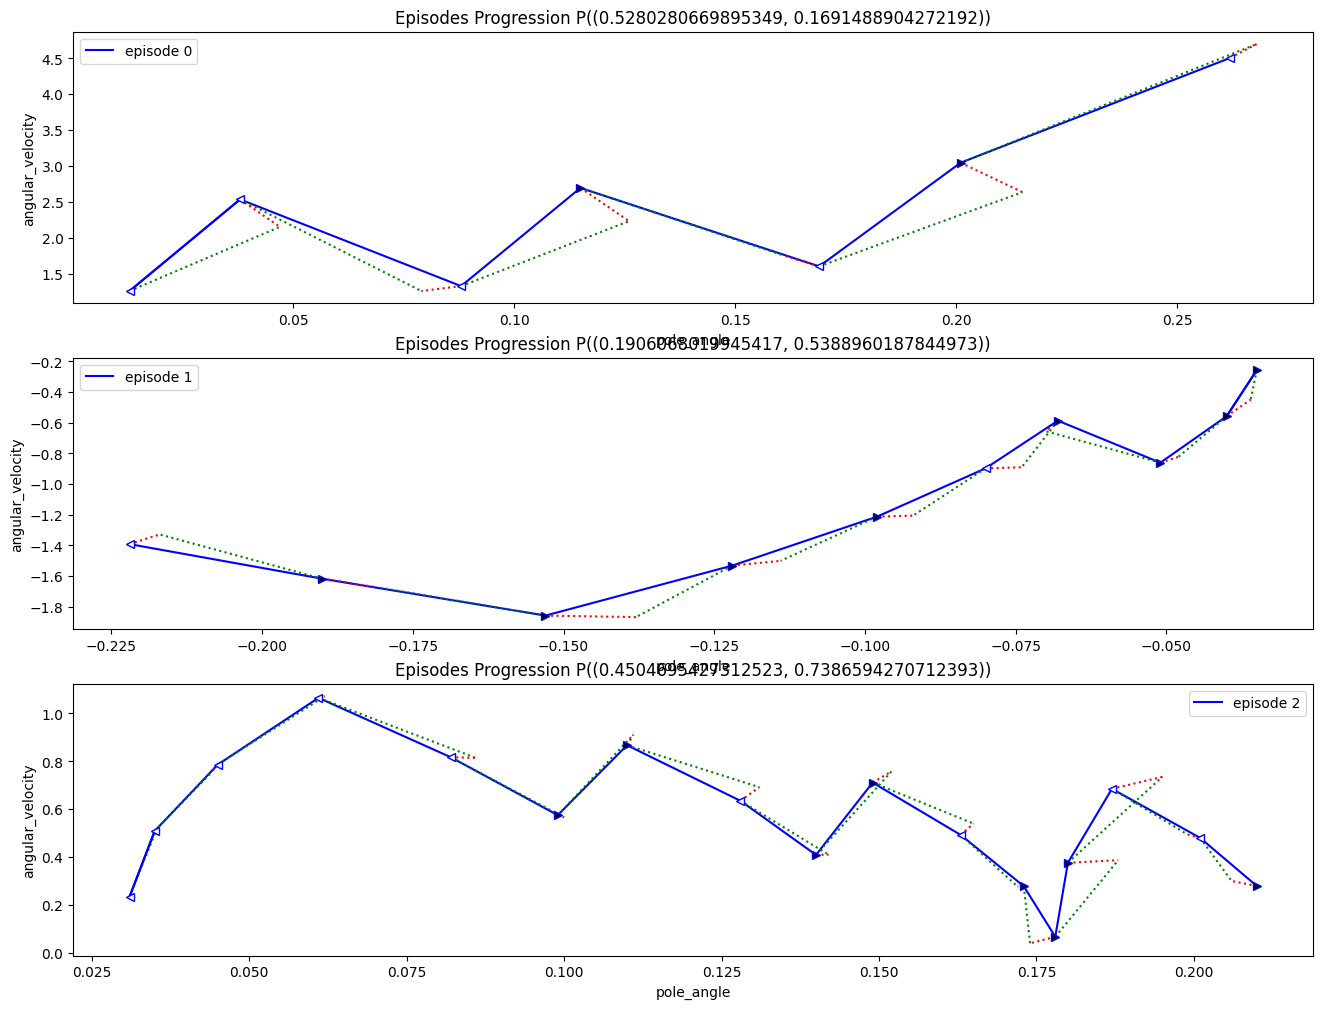

In [22]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()

## Cluster

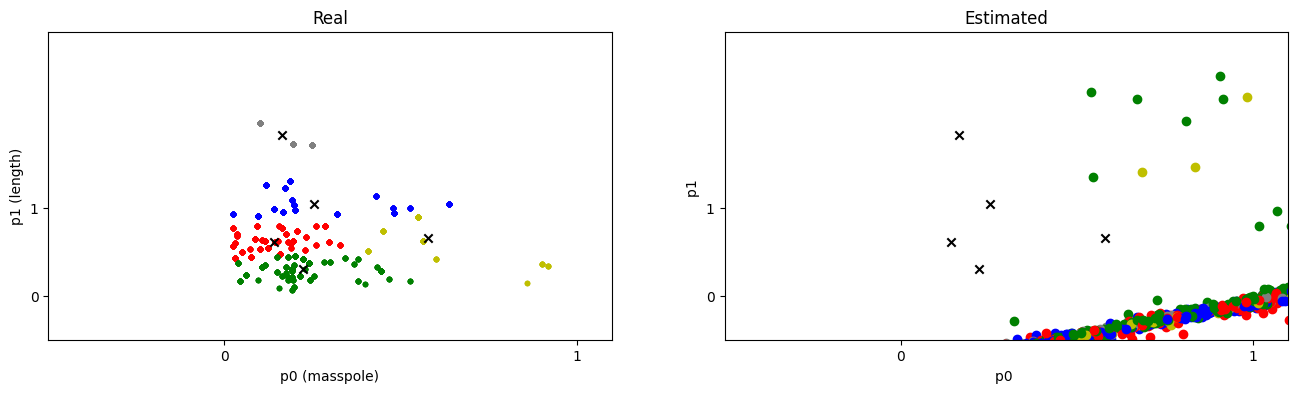

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
data.plot_clusters(axs, results)
plt.show()

# Save

In [ ]:
# import pickle

# exp = {
#     "data": data,
#     "model": model 
# }

# nome_do_arquivo = 'regular.pkl'
# with open(nome_do_arquivo, 'wb') as arquivo:
#     pickle.dump(exp, arquivo)